In [2]:
import csv
import h5py
import json

import matplotlib.pyplot as plt
import numpy as np

In [3]:
def load_nested_dict_from_hdf5(filename):
    def _load_dict(group):
        result = {}
        for key in group.keys():
            if isinstance(group[key], h5py.Group):
                result[key] = _load_dict(group[key])
            else:
                result[key] = group[key][()]  # Load dataset
        
        # Load attributes (scalars)
        for key, value in group.attrs.items():
            result[key] = value
            
        return result
    
    with h5py.File(filename, 'r') as f:
        return _load_dict(f)

def print_tree(data, max_level=None):
    def __print_tree_recursive(root, level=0):
        if isinstance(root, dict):
            if not max_level is None and level == max_level:
                return
            level_str = '- '*level
            for key in root:
                print(f'{level_str}{key}')
                __print_tree_recursive(root[key], level+1)
    __print_tree_recursive(data)

In [4]:
data_filename = 'current_correlations_data.h5'

data = load_nested_dict_from_hdf5(data_filename)

In [5]:
print_tree(data, max_level=3)

data
- coupling_point_1
- - disordered
- - highest
- - highest_postselection
- coupling_point_2
- - highest
- - highest_postselection
- coupling_point_3
- - disordered
- - highest
- - highest_postselection
- coupling_point_4
- - highest
- - highest_postselection
- - lowest
- coupling_point_5
- - disordered
- - highest
- - highest_postselection
- coupling_point_6
- - highest
- - highest_postselection
simulation
- highest
- - 0.01
- - 0.1
- - 0.2
- - 0.3
- - 0.5
- - 0.8
- - 1.0
- - 10.0
- - 2.0
- - 5.0
- - 50.0
- - no_dephasing
- - no_dephasing_ramp
- - real
- lowest
- - no_dephasing


In [6]:
eigenstate = 'highest_postselection'

eigenstate_base = eigenstate.split('_')[0]

[(1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7), (7, 8)]


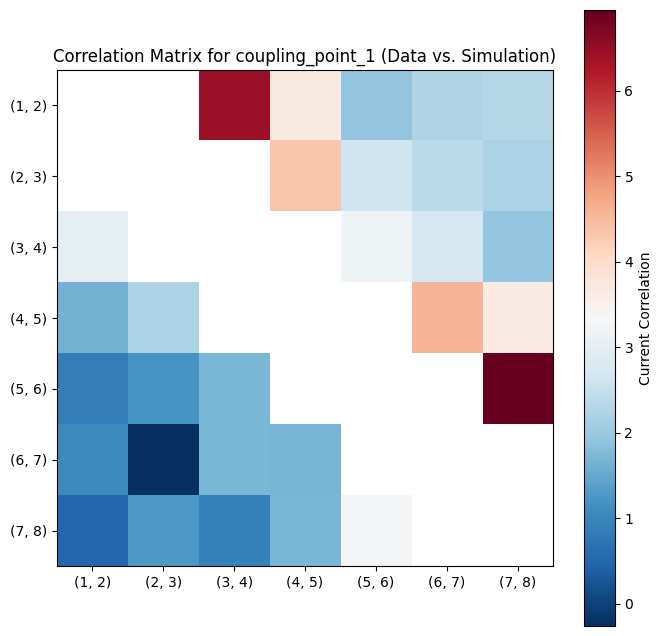

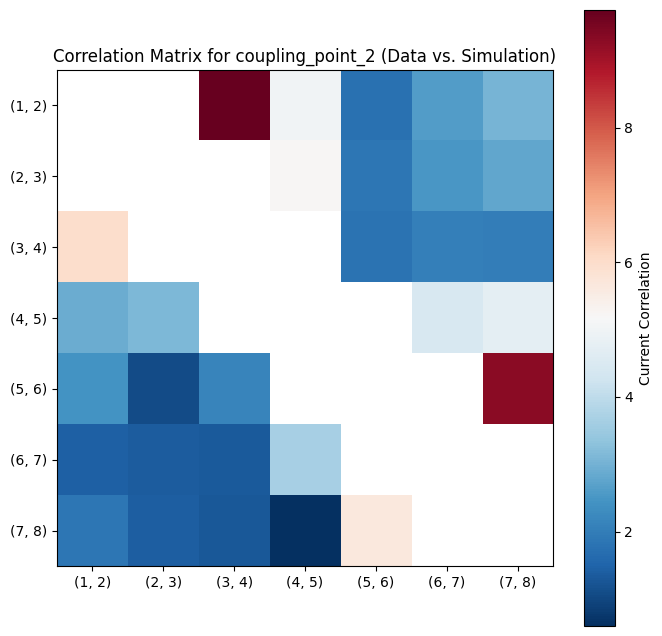

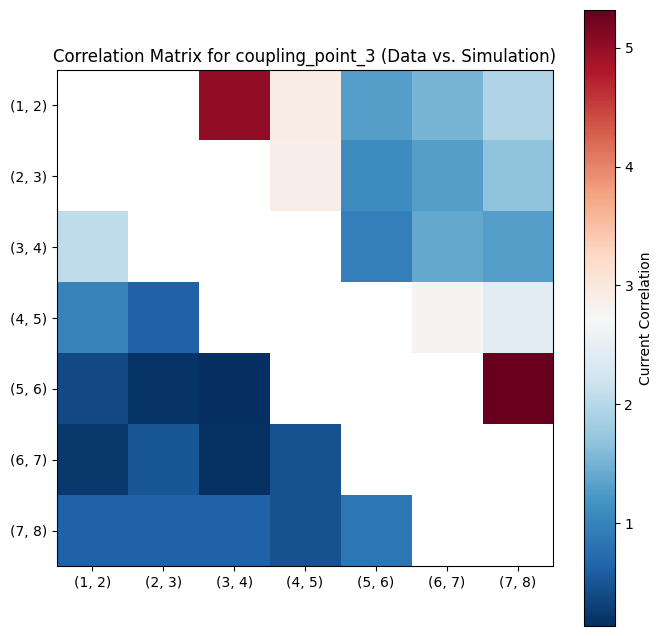

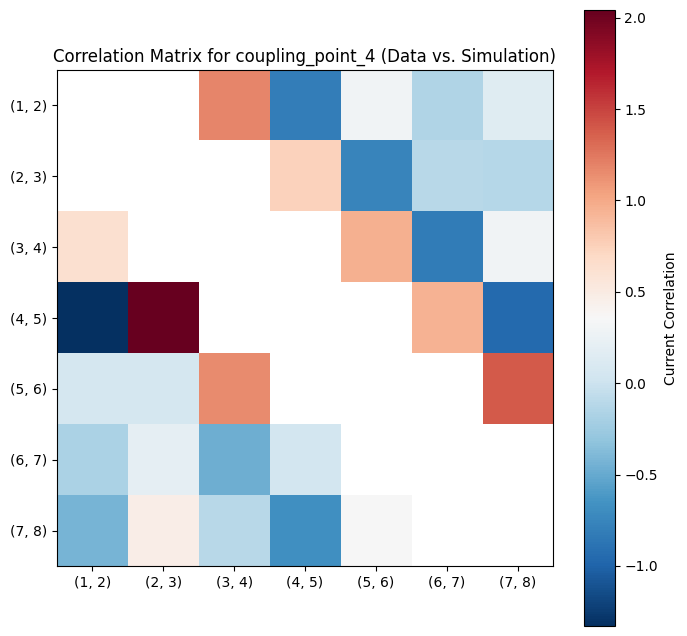

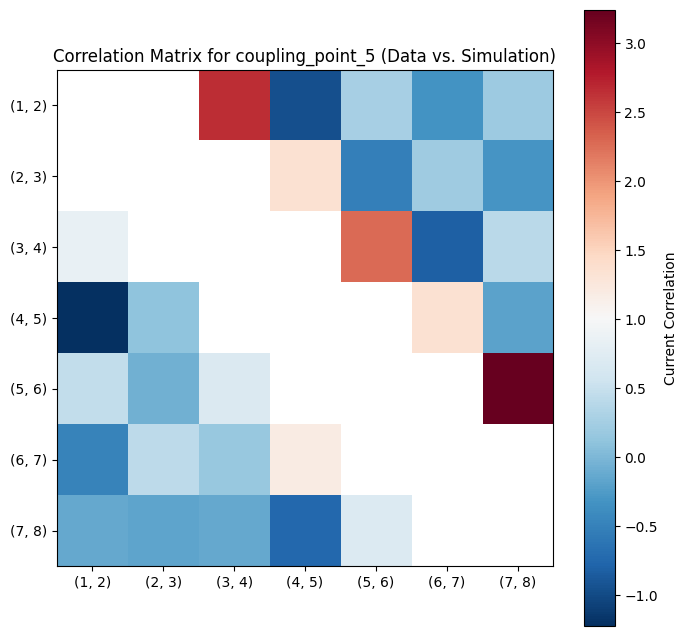

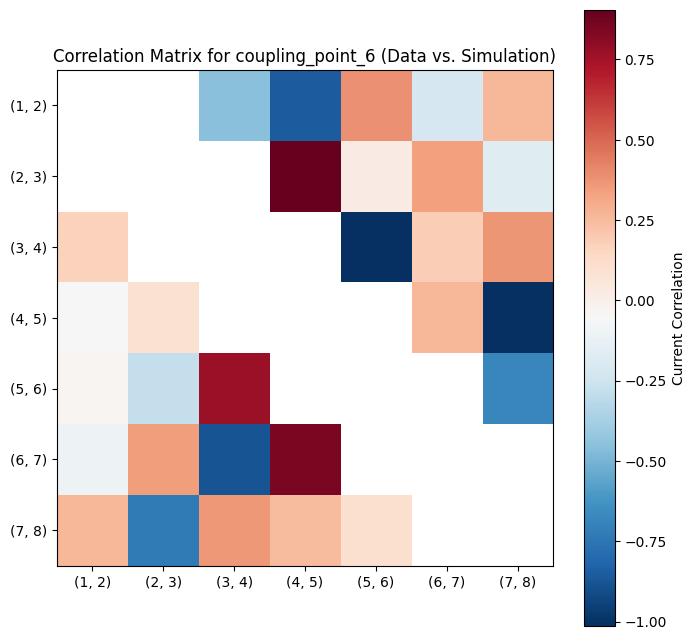

In [7]:
all_coupling_points = [f'coupling_point_{i}' for i in range(1, 7)]

all_pairs = [(i,i+1) for i in range(1,8)]
print(all_pairs)

dephasing = 'real'

for coupling_point in all_coupling_points:

    if coupling_point in data['data']:

        if eigenstate in data['data'][coupling_point]:
            coupling_point_data = data['data'][coupling_point][eigenstate]
        elif eigenstate_base in data['data'][coupling_point]:
            coupling_point_data = data['data'][coupling_point][eigenstate_base]
        else:
            print(f'No data for {coupling_point} with eigenstate {eigenstate} or base {eigenstate_base}')
            continue
        coupling_point_sim = data['simulation'][eigenstate_base][dephasing][coupling_point]

        correlation_matrix = np.zeros((len(all_pairs),len(all_pairs)))

        for i in range(len(all_pairs)):
            pair_1 = all_pairs[i]
            for j in range(i, len(all_pairs)):
                pair_2 = all_pairs[j]
                if set(pair_1).intersection(set(pair_2)):
                    correlation_matrix[i, j] = np.nan
                    correlation_matrix[j, i] = np.nan
                else:
                    correlation_data = coupling_point_data[str((pair_1, pair_2))]['current_correlation_value']
                    correlation_sim_BS = coupling_point_sim[str((pair_1, pair_2))]['current_correlation_BS_value']

                    correlation_matrix[j, i] = correlation_data
                    correlation_matrix[i, j] = correlation_sim_BS
    else:
        # for coupling points with no data, fill with randoms for now
        correlation_matrix = np.random.rand(len(all_pairs), len(all_pairs))

    fig, ax = plt.subplots(figsize=(8,8))
    im = ax.imshow(correlation_matrix, cmap='RdBu_r')
    ax.set_xticks(np.arange(len(all_pairs)))
    ax.set_xticklabels(all_pairs)
    ax.set_yticks(np.arange(len(all_pairs)))
    ax.set_yticklabels(all_pairs)
    fig.colorbar(im, ax=ax, label='Current Correlation')
    
    plt.title(f'Correlation Matrix for {coupling_point} (Data vs. Simulation)')
    plt.show()

    # default is highest eigenstate and real dephasing
    correlation_matrix_filename = f'plots\\correlation_matrices\\{coupling_point}_correlation_matrix.csv'
    with open(correlation_matrix_filename, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        for i, pair_1 in enumerate(all_pairs):
            row = list(correlation_matrix[i, :])
            writer.writerow(row)
    


In [8]:
for coupling_point in all_coupling_points:
    if coupling_point in data['data']:
        print()
        print(f'{coupling_point}')
        print()
        # print_tree(data['data'][coupling_point]['highest'], max_level=2)
        print(data['data'][coupling_point]['highest']['current_correlation_total'])


coupling_point_1

8.168031446073723

coupling_point_2

16.561978979573674

coupling_point_3

6.545125826728219

coupling_point_4

0.2930667019801857

coupling_point_5

0.050390634622124036

coupling_point_6

0.22408837726148834


In [9]:
# all_coupling_points = [f'coupling_point_{i}' for i in range(1, 7)]

# all_pairs = [(i,i+1) for i in range(1,8)]
# print(all_pairs)

# dephasing = 'real'

# for coupling_point in all_coupling_points:

#     if coupling_point in data['data']:

#         coupling_point_data = data['data'][coupling_point]['highest']
#         print(data['data'][coupling_point]['highest']['current_correlation_total'])
#         coupling_point_sim = data['simulation']['highest'][dephasing][coupling_point]

#         print(coupling_point)
#         print(coupling_point_data.keys())

#         distance_to_current_correlation_error = coupling_point_data['distance_to_current_correlation_error']
#         distance_to_current_correlation_value = coupling_point_data['distance_to_current_correlation_value']
        
#         current_correlation_averages = coupling_point_data['current_correlation_averages']
    


In [10]:
### export total chiral currents explicitly

values = []
errors = []
for coupling_point in all_coupling_points:
    if coupling_point in data['data']:
        coupling_point_data = data['data'][coupling_point]['highest']
        value = coupling_point_data['current_correlation_total']
        if 'current_correlation_total_error' in coupling_point_data:
            error = coupling_point_data['current_correlation_total_error']
        else:
            error = 50
    else:
        value = 0
        error = 50
    values.append(value)
    errors.append(error)

print(values)
print(errors)

with open('plots/current_correlation_totals.csv', 'w', newline='\n') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(values)
    writer.writerow(errors)

[8.168031446073723, 16.561978979573674, 6.545125826728219, 0.2930667019801857, 0.050390634622124036, 0.22408837726148834]
[0.0618092525530903, 50, 0.1401662991279052, 50, 50, 50]


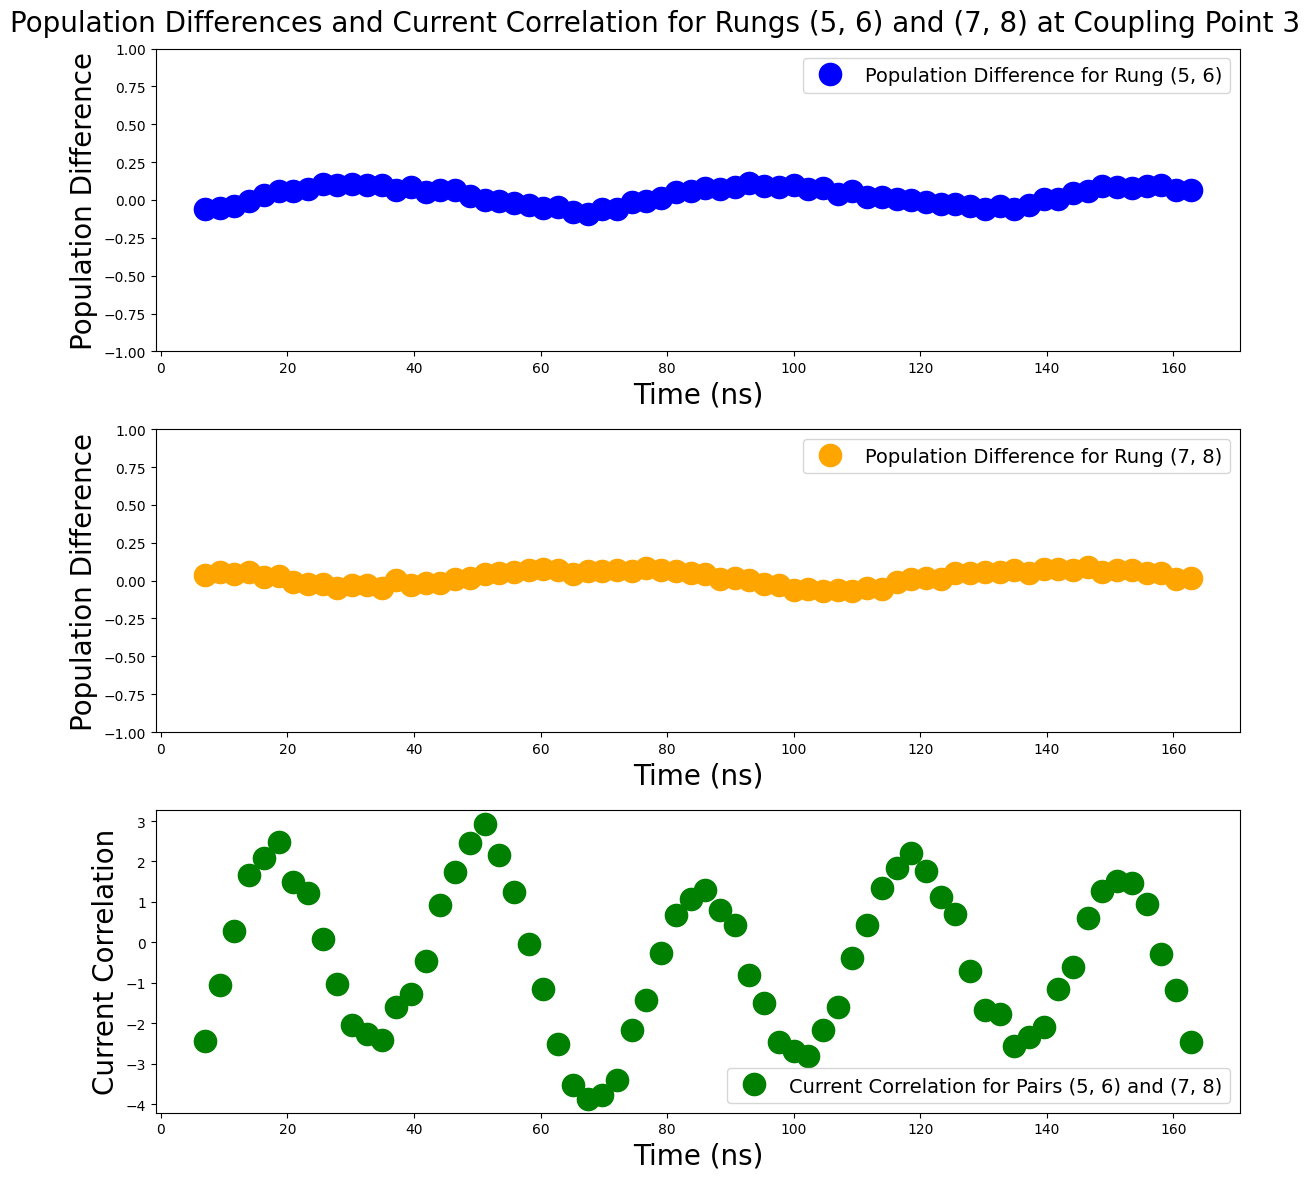

In [11]:
### export two population swaps and one correlations into csv for figure 2

coupling_point = 3

correlation_pair = ((5,6),(7,8))

start_index = 3

pair_1, pair_2 = correlation_pair

swap_1_data = data['data'][f'coupling_point_{coupling_point}']['highest'][str(correlation_pair)]['population_difference'][0,start_index:]

swap_2_data = data['data'][f'coupling_point_{coupling_point}']['highest'][str(correlation_pair)]['population_difference'][1,start_index:]

correlation_data = data['data'][f'coupling_point_{coupling_point}']['highest'][str(correlation_pair)]['current_correlation'][start_index:]

times = data['data'][f'coupling_point_{coupling_point}']['highest'][str(correlation_pair)]['times'][start_index:]

fig, axes = plt.subplots(3,1, figsize=(12, 12))


fontsize = 20
axes[0].plot(times, swap_1_data, color='blue', linestyle='', marker='o', ms=16, label=f'Population Difference for Rung {pair_1}')
axes[0].set_xlabel('Time (ns)', fontsize=fontsize)
axes[0].set_ylabel('Population Difference', fontsize=fontsize)
axes[0].legend(fontsize=fontsize - 6)
axes[0].set_ylim(-1, 1)

axes[1].plot(times, swap_2_data, color='orange', linestyle='', marker='o', ms=16, label=f'Population Difference for Rung {pair_2}')
axes[1].set_xlabel('Time (ns)', fontsize=fontsize)
axes[1].set_ylabel('Population Difference', fontsize=fontsize)
axes[1].legend(fontsize=fontsize - 6)
axes[1].set_ylim(-1, 1)

axes[2].plot(times, correlation_data, color='green', linestyle='', marker='o', ms=16, label=f'Current Correlation for Pairs {pair_1} and {pair_2}')
axes[2].set_xlabel('Time (ns)', fontsize=fontsize)
axes[2].set_ylabel('Current Correlation', fontsize=fontsize)
axes[2].legend(fontsize=fontsize - 6)

plt.suptitle(f'Population Differences and Current Correlation for Rungs {pair_1} and {pair_2} at Coupling Point {coupling_point}', fontsize=fontsize)
plt.tight_layout()
plt.show()


### write to csv

fig_2_filename = f'plots/figure_2_data.csv'

with open(fig_2_filename, 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(times)
    writer.writerow(swap_1_data)
    writer.writerow(swap_2_data)
    writer.writerow(correlation_data)